# Lab: Hồi quy logistic

Trong Lab chưa được phân loại này, bạn sẽ 
- Khám phá hàm sigmoid (còn được gọi là hàm logistic)
- Khám phá logistic regression; sử dụng hàm sigmoid


In [ ]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from plt_one_addpt_onclick import plt_one_addpt_onclick
from lab_utils_common import draw_vthresh
plt.style.use('./deeplearning.mplstyle')

## Hàm Sigmoid hoặc Logistic
<img align="left" src="./images/C1_W3_LogisticRegression_left.png"     style=" width:300px; padding: 10px; " >Như đã thảo luận trong các video bài giảng, đối với nhiệm vụ phân loại, chúng ta có thể bắt đầu bằng cách sử dụng mô hình linear regression của mình
$f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot  \mathbf{x}^{(i)} + b$
, để dự đoán $y$ cho trước $x$. 
- Tuy nhiên, chúng ta muốn các dự đoán của mô hình phân loại của chúng ta nằm trong khoảng từ 0 đến 1 vì biến đầu ra $y$ của chúng ta là 0 hoặc 1. 
- Điều này có thể được thực hiện bằng cách sử dụng "hàm sigmoid" ánh xạ tất cả các giá trị đầu vào thành các giá trị trong khoảng từ 0 đến 1. 


Hãy triển khai hàm sigmoid và tự mình xem điều này.

## Công thức hàm Sigmoid

Công thức cho hàm sigmoid như sau - $g(z) = \frac{1}{1+e^{-z}}$

Trong trường hợp logistic regression, z (đầu vào của hàm sigmoid), là đầu ra của mô hình linear regression. 
- Trong trường hợp chỉ có một ví dụ, $z$ là vô hướng.
- Trong trường hợp có nhiều ví dụ, $z$ có thể là một vectơ bao gồm các giá trị $m$, một giá trị cho mỗi ví dụ. 
- Việc triển khai chức năng sigmoid phải bao gồm cả hai định dạng đầu vào tiềm năng này.
Hãy triển khai điều này trong Python.


NumPy có một hàm gọi là [`exp()`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html), hàm này cung cấp một cách thuận tiện để tính số mũ ( $e^{z}$) của tất cả các phần tử trong mảng đầu vào (`z`).
 
Nó cũng hoạt động với một số duy nhất làm đầu vào, như hiển thị bên dưới.


In [2]:
# Đầu vào là một mảng.
input_array = np.array([1,2,3])
exp_array = np.exp(input_array)

print("Input to exp:", input_array)
print("Output of exp:", exp_array)

# Đầu vào là một số duy nhất
input_val = 1  
exp_val = np.exp(input_val)

print("Input to exp:", input_val)
print("Output of exp:", exp_val)

Input to exp: [1 2 3]
Output of exp: [ 2.72  7.39 20.09]
Input to exp: 1
Output of exp: 2.718281828459045


Hàm `sigmoid` được triển khai trong python như hiển thị trong ô bên dưới.


In [3]:
def sigmoid(z):
    """
    Compute the sigmoid of z

    Args:
        z (ndarray): A scalar, numpy array of any size.

    Returns:
        g (ndarray): sigmoid(z), with the same shape as z
         
    """
    g = 1 / (1 + np.exp(-z))
    return g

Hãy xem đầu ra của hàm này là gì với các giá trị khác nhau của `z`


In [4]:
# Tạo một mảng các giá trị cách đều nhau trong khoảng từ -10 đến 10
z_tmp = np.arange(-10,11)

# Sử dụng hàm được triển khai ở trên để nhận các giá trị sigmoid
y = sigmoid(z_tmp)

# Code in đẹp 2 mảng cạnh nhau
np.set_printoptions(precision=3) 
print("Input (z), Output (sigmoid(z))")
print(np.c_[z_tmp, y])

Input (z), Output (sigmoid(z))
[[-1.000e+01  4.540e-05]
 [-9.000e+00  1.234e-04]
 [-8.000e+00  3.354e-04]
 [-7.000e+00  9.111e-04]
 [-6.000e+00  2.473e-03]
 [-5.000e+00  6.693e-03]
 [-4.000e+00  1.799e-02]
 [-3.000e+00  4.743e-02]
 [-2.000e+00  1.192e-01]
 [-1.000e+00  2.689e-01]
 [ 0.000e+00  5.000e-01]
 [ 1.000e+00  7.311e-01]
 [ 2.000e+00  8.808e-01]
 [ 3.000e+00  9.526e-01]
 [ 4.000e+00  9.820e-01]
 [ 5.000e+00  9.933e-01]
 [ 6.000e+00  9.975e-01]
 [ 7.000e+00  9.991e-01]
 [ 8.000e+00  9.997e-01]
 [ 9.000e+00  9.999e-01]
 [ 1.000e+01  1.000e+00]]


Các giá trị ở cột bên trái là `z` và các giá trị ở cột bên phải là `sigmoid(z)`. Như bạn có thể thấy, các giá trị đầu vào của sigmoid nằm trong khoảng từ -10 đến 10 và các giá trị đầu ra nằm trong khoảng từ 0 đến 1. 

Bây giờ, hãy thử vẽ đồ thị hàm này bằng thư viện `matplotlib`.


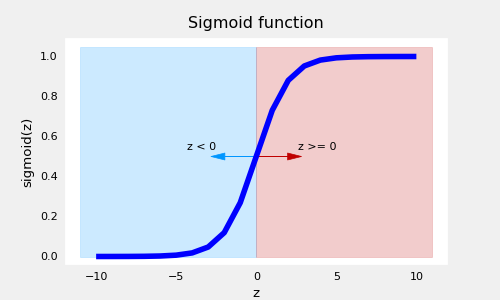

In [5]:
# Vẽ đồ thị z và sigmoid(z)
fig,ax = plt.subplots(1,1,figsize=(5,3))
ax.plot(z_tmp, y, c="b")

ax.set_title("Sigmoid function")
ax.set_ylabel('sigmoid(z)')
ax.set_xlabel('z')
draw_vthresh(ax,0)

Như bạn có thể thấy, hàm sigmoid tiến đến `0` khi `z` tiến đến giá trị âm lớn và tiến đến `1` khi `z` tiến đến giá trị dương lớn.


## Hồi quy logistic
<img align="left" src="./images/C1_W3_LogisticRegression_right.png"     style=" width:300px; padding: 10px; " > Mô hình logistic regression áp dụng sigmoid cho mô hình linear regression quen thuộc như hình dưới đây:

$f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x}^{(i)} + b )$

Ở đây

$g(z) = \frac{1}{1+e^{-z}}$


Hãy áp dụng logistic regression cho ví dụ dữ liệu phân loại về phân loại khối u.  
Đầu tiên, tải các ví dụ và giá trị ban đầu cho các tham số.


In [ ]:
x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0,  0, 0, 1, 1, 1])

w_in = np.zeros((1))
b_in = 0

Hãy thử các bước sau:
- Nhấp vào 'Chạy hồi quy logistic' để tìm mô hình logistic regression tốt nhất cho dữ liệu training đã cho
    - Lưu ý mô hình thu được khá phù hợp với dữ liệu.
    - Lưu ý, dòng màu cam là '$z$' hoặc $\mathbf{w} \cdot \mathbf{x}^{(i)} + b$ ở trên. Nó không khớp với đường trong mô hình linear regression.
Cải thiện hơn nữa những kết quả này bằng cách áp dụng *ngưỡng*. 
- Đánh dấu vào ô 'Chuyển đổi ngưỡng 0,5' để hiển thị dự đoán nếu áp dụng ngưỡng.
    - Những lời tiên đoán này có vẻ hay đấy. Các dự đoán khớp với dữ liệu
    - Bây giờ, hãy thêm các điểm dữ liệu khác trong phạm vi kích thước khối u lớn (gần 10) và chạy lại logistic regression.
    - không giống như mô hình linear regression, mô hình này tiếp tục đưa ra dự đoán chính xác


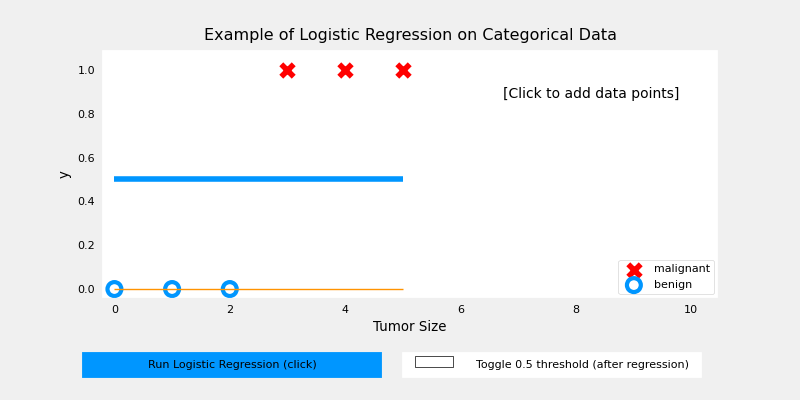

In [ ]:
plt.close('all') 
addpt = plt_one_addpt_onclick( x_train,y_train, w_in, b_in, logistic=True)

## Chúc mừng!
Bạn đã khám phá cách sử dụng hàm sigmoid trong logistic regression.
